# Test: CaSR File Download

In this notebook, we will download data from https://hpfx.collab.science.gc.ca/~scar700/rcas-casr/download_CaSR_regions_var_period.html and visualize them.



## Download Paths





### Variables: Forcing

| Variable            | Long Name                                       | Type     | Unit  | Level   | Freq.  | Grid Range                                    | Year |
|---------------------|-------------------------------------------------|----------|-------|---------|--------|-----------------------------------------------|------|
| CaSR_v3.2_P_PR0_SFC | Quantity of precipitation (1h)                  | forecast | m     | surface | 1 hour | rlon: 141-175, 176-210 rlat: 421-455, 456-490 | 2024 |
| CaSR_v3.2_P_TT_1.5m | Air temperature                                 | forecast | °C    | 1.5m    | 1 hour | rlon: 141-175, 176-210 rlat: 421-455, 456-490 | 2024 |
| CaSR_v3.2_P_HU_1.5m | Specific humidity                               | forecast | kg/kg | 1.5m    | 1 hour | rlon: 141-175, 176-210 rlat: 421-455, 456-490 | 2024 |
| CaSR_v3.2_P_FB_SFC  | Downward solar flux                             | forecast | W/m²  | surface | 1 hour | rlon: 141-175, 176-210 rlat: 421-455, 456-490 | 2024 |
| CaSR_v3.2_P_FI_SFC  | Surface incoming infrared flux                  | forecast | W/m²  | surface | 1 hour | rlon: 141-175, 176-210 rlat: 421-455, 456-490 | 2024 |
| CaSR_v3.2_P_PN_SFC  | Sea level pressure                              | forecast | mb    | surface | 1 hour | rlon: 141-175, 176-210 rlat: 421-455, 456-490 | 2024 |
| CaSR_v3.2_P_UUC_10m | Corrected U-component of the wind (West-East)   | forecast | kts   | 10m     | 1 hour | rlon: 141-175, 176-210 rlat: 421-455, 456-490 | 2024 |
| CaSR_v3.2_P_VVC_10m | Corrected V-component of the wind (South-North) | forecast | kts   | 10m     | 1 hour | rlon: 141-175, 176-210 rlat: 421-455, 456-490 | 2024 |

### DownLoad Command

**wget -c -i CaSRv3p2_file-list.txt -P target-directory -B base-URL**

where

**-c**: resume getting a partially-downloaded file

**CaSRv3p2_file-list.txt**: text file containing a list of desired files as can be obtained 

**base-URL**: https://hpfx.collab.science.gc.ca/~scar700/rcas-casr/data/CaSRv3.2/netcdf_tile/

**target-directory**: directory where downloaded file will be saved locally

## Download and Integration

### Download Command

Note that we need to download the big files into /ocean. 

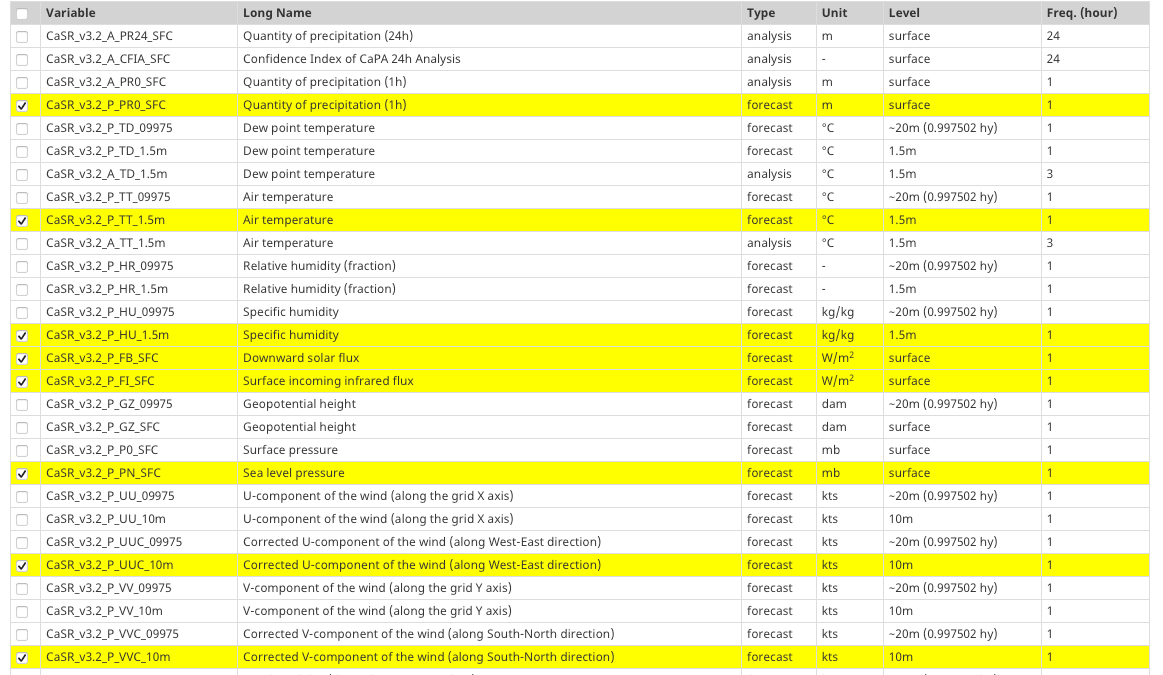

In [1]:
# Download files using given URL and commands
import os
import subprocess

import os
import requests
from concurrent.futures import ThreadPoolExecutor, as_completed
from tqdm import tqdm

# ================= 配置区域 =================
file_list = "/home/jqiu/Programing/Projects/analysis-junqi/Atmospheric_Forcing/Data_CaSR/CaSRv3p2_file-list_2024.txt"
target_dir = "/home/jqiu/Programing/Projects/analysis-junqi/Atmospheric_Forcing/Data_CaSR/Data_2024"
base_url = "https://hpfx.collab.science.gc.ca/~scar700/rcas-casr/data/CaSRv3.2/netcdf_tile/"

# 最大并发线程数（建议 4-8，太高可能会被服务器封 IP）
MAX_WORKERS = 5 
# ============================================

os.makedirs(target_dir, exist_ok=True)

def download_file(filename):
    """负责处理单个文件下载的核心函数，支持断点续传"""
    full_url = base_url + filename if not filename.startswith("http") else filename
    # 提取纯文件名，防止带路径导致报错
    safe_filename = filename.split('/')[-1] 
    target_path = os.path.join(target_dir, safe_filename)
    
    try:
        # 1. 先发送 HEAD 请求，只获取文件的基本信息（不下载内容），目的是拿到服务器上的文件总大小
        head_response = requests.head(full_url, timeout=10)
        head_response.raise_for_status()
        remote_size = int(head_response.headers.get('content-length', 0))
        
        # 2. 检查本地是否已经有这个文件，以及它的大小
        local_size = 0
        if os.path.exists(target_path):
            local_size = os.path.getsize(target_path)
            
        # 3. 核心逻辑：比对大小
        if remote_size > 0 and local_size == remote_size:
            return True, f"Skipped (Already fully downloaded)" # 本地与云端一样大，直接跳过
            
        headers = {}
        mode = 'wb' # 默认覆盖写入
        
        if 0 < local_size < remote_size:
            # 本地有文件但没下完，构造 Range 请求头告诉服务器“从这里接着传”
            headers['Range'] = f"bytes={local_size}-"
            mode = 'ab' # 调整为追加写入模式 (append binary)
            
        elif local_size > remote_size:
            # 异常情况：本地文件比服务器还大（可能文件损坏），从头开始下
            local_size = 0 
            
        # 4. 开始实际下载 (stream=True 保证内存不会爆掉)
        with requests.get(full_url, headers=headers, stream=True, timeout=15) as r:
            r.raise_for_status()
            with open(target_path, mode) as f:
                for chunk in r.iter_content(chunk_size=8192): # 每次写入 8KB
                    if chunk:
                        f.write(chunk)
                        
        return True, "Success"
        
    except Exception as e:
        return False, f"Failed: {str(e)}"

# ================= 主程序 =================
if __name__ == "__main__":
    if not os.path.exists(file_list):
        print(f"No path found: {file_list}")
    else:
        # 读取并过滤空行
        with open(file_list, 'r') as f:
            files_to_download = [line.strip() for line in f if line.strip()]
            
        total_files = len(files_to_download)
        print(f"Target Path: {target_dir}")
        print(f" Max Workers: {MAX_WORKERS}  Total Files: {total_files}\n")
        
        success_count = 0
        failed_files = []
        
        # 使用线程池并发执行下载
        with ThreadPoolExecutor(max_workers=MAX_WORKERS) as executor:
            # 提交所有任务到线程池，并将任务与文件名绑定
            future_to_file = {executor.submit(download_file, fname): fname for fname in files_to_download}
            
            # 使用 tqdm 包装 as_completed，哪个文件先下完，进度条就涨一下
            for future in tqdm(as_completed(future_to_file), total=total_files, desc="总进度", unit="file"):
                fname = future_to_file[future]
                try:
                    is_success, msg = future.result()
                    if is_success:
                        success_count += 1
                    else:
                        failed_files.append((fname, msg))
                        # 只有在发生错误时才在终端打印，不干扰进度条
                        tqdm.write(f" {fname} -> {msg}")
                except Exception as exc:
                    failed_files.append((fname, str(exc)))
                    tqdm.write(f" {fname} Fatal Error: {exc}")
                    
        # 最终统计报告
        print("\n" + "="*40)
        print(f"Success: {success_count}/{total_files}")
        if failed_files:
            print(f"Failed: {len(failed_files)}")
            print("Error Details:")
            for name, error in failed_files:
                print(f" - {name}: {error}")
        print("="*40)

Target Path: /home/jqiu/Programing/Projects/analysis-junqi/Atmospheric_Forcing/Data_CaSR/Data_2024
 Max Workers: 5  Total Files: 48



总进度: 100%|██████████| 48/48 [00:43<00:00,  1.10file/s]


Success: 48/48


### Data Integration

In [ ]:
import xarray as xr
import glob
import os
import warnings
from tqdm import tqdm

# 禁用 HDF5 文件锁，屏蔽底层报错
os.environ['HDF5_USE_FILE_LOCKING'] = 'FALSE'
os.environ['HDF5_DISABLE_VERSION_CHECK'] = '1'

# 原始数据目录
base_dir = '/home/jqiu/Programing/Projects/analysis-junqi/Atmospheric_Forcing/Data_CaSR/Data_2024/'
# 新建一个专门存放合并后数据的独立目录
output_dir = '/home/jqiu/Programing/Projects/analysis-junqi/Atmospheric_Forcing/Data_CaSR/Merged_Data_2024/'
os.makedirs(output_dir, exist_ok=True)

variables = [
    'P_FB_SFC', 'P_FI_SFC', 'P_HU_1.5m', 'P_PN_SFC', 
    'P_PR0_SFC', 'P_TT_1.5m', 'P_UUC_10m', 'P_VVC_10m'
]

for var in tqdm(variables, desc="Merging Variables", unit="var"):
    
    # 因为输出目录分开了，这里的搜索绝对不会再抓到合并后的文件
    search_pattern = os.path.join(base_dir, f'CaSR_v3.2_{var}_*.nc')
    all_files = sorted(glob.glob(search_pattern))
    
    # 文件体检（过滤掉太小的损坏文件）
    valid_files = [f for f in all_files if os.path.getsize(f) > 10240]
    invalid_count = len(all_files) - len(valid_files)
    
    if invalid_count > 0:
        tqdm.write(f"Attention: {var} Found {invalid_count} corrupted files, automatically skipped!")
        
    if not valid_files:
        tqdm.write(f"Error: {var} No valid files found, skipping variable.")
        continue

    try:
        with warnings.catch_warnings():
            warnings.simplefilter("ignore", FutureWarning)
            
            # chunks='auto' 依然保留，防止你的 Jupyter Kernel 因为内存不足而崩溃
            combined = xr.open_mfdataset(
                valid_files, 
                combine='by_coords', 
                parallel=True,
                data_vars='minimal', 
                engine='netcdf4',
                chunks='auto' 
            )
        
        ds = xr.open_dataset(valid_files[0], engine='netcdf4')
        combined['rotated_pole'] = ds['rotated_pole']
        
        # 【关键改动 2】：改动输出路径和前缀，保存到新文件夹，并加上 Merged_ 前缀
        output_file = os.path.join(output_dir, f"Merged_CaSR_v3.2_{var}_2024.nc")
        
        # 写入文件
        combined.to_netcdf(output_file, unlimited_dims='time')
        tqdm.write(f"Successfully merged {var} into {output_file}")
        
        # 释放内存
        combined.close()
        ds.close()
        
    except Exception as e:
        tqdm.write(f"Error processing {var}: {e}")

print("\n All variables processed! Merged files are saved in Merged_Data_2024 folder.")

Merging Variables:   0%|          | 0/8 [00:00<?, ?var/s]HDF5-DIAG: Error detected in HDF5 (1.14.6) thread 1:
  #000: H5F.c line 496 in H5Fis_accessible(): unable to determine if file is accessible as HDF5
    major: File accessibility
    minor: Not an HDF5 file
  #001: H5VLcallback.c line 3913 in H5VL_file_specific(): file specific failed
    major: Virtual Object Layer
    minor: Can't operate on object
  #002: H5VLcallback.c line 3848 in H5VL__file_specific(): file specific failed
    major: Virtual Object Layer
    minor: Can't operate on object
  #003: H5VLnative_file.c line 344 in H5VL__native_file_specific(): error in HDF5 file check
    major: File accessibility
    minor: Can't get value
  #004: H5Fint.c line 1055 in H5F__is_hdf5(): unable to open file
    major: File accessibility
    minor: Unable to initialize object
  #005: H5FD.c line 787 in H5FD_open(): can't open file
    major: Virtual File Layer
    minor: Unable to open file
  #006: H5FDsec2.c line 323 in H5FD__sec2

Successfully merged P_FB_SFC into /home/jqiu/Programing/Projects/analysis-junqi/Atmospheric_Forcing/Data_CaSR/Merged_Data_2024/Merged_CaSR_v3.2_P_FB_SFC_2024.nc


HDF5-DIAG: Error detected in HDF5 (1.14.6) thread 1:
  #000: H5F.c line 496 in H5Fis_accessible(): unable to determine if file is accessible as HDF5
    major: File accessibility
    minor: Not an HDF5 file
  #001: H5VLcallback.c line 3913 in H5VL_file_specific(): file specific failed
    major: Virtual Object Layer
    minor: Can't operate on object
  #002: H5VLcallback.c line 3848 in H5VL__file_specific(): file specific failed
    major: Virtual Object Layer
    minor: Can't operate on object
  #003: H5VLnative_file.c line 344 in H5VL__native_file_specific(): error in HDF5 file check
    major: File accessibility
    minor: Can't get value
  #004: H5Fint.c line 1055 in H5F__is_hdf5(): unable to open file
    major: File accessibility
    minor: Unable to initialize object
  #005: H5FD.c line 787 in H5FD_open(): can't open file
    major: Virtual File Layer
    minor: Unable to open file
  #006: H5FDsec2.c line 323 in H5FD__sec2_open(): unable to open file: name = '/home/jqiu/Programi

Successfully merged P_FI_SFC into /home/jqiu/Programing/Projects/analysis-junqi/Atmospheric_Forcing/Data_CaSR/Merged_Data_2024/Merged_CaSR_v3.2_P_FI_SFC_2024.nc


Merging Variables:  38%|███▊      | 3/8 [01:35<02:41, 32.38s/var]

...

Successfully merged P_TT_1.5m into /home/jqiu/Programing/Projects/analysis-junqi/Atmospheric_Forcing/Data_CaSR/Merged_Data_2024/Merged_CaSR_v3.2_P_TT_1.5m_2024.nc


Merging Variables:  88%|████████▊ | 7/8 [03:56<00:35, 35.17s/var]

Successfully merged P_UUC_10m into /home/jqiu/Programing/Projects/analysis-junqi/Atmospheric_Forcing/Data_CaSR/Merged_Data_2024/Merged_CaSR_v3.2_P_UUC_10m_2024.nc


HDF5-DIAG: Error detected in HDF5 (1.14.6) thread 1:
  #000: H5F.c line 496 in H5Fis_accessible(): unable to determine if file is accessible as HDF5
    major: File accessibility
    minor: Not an HDF5 file
  #001: H5VLcallback.c line 3913 in H5VL_file_specific(): file specific failed
    major: Virtual Object Layer
    minor: Can't operate on object
  #002: H5VLcallback.c line 3848 in H5VL__file_specific(): file specific failed
    major: Virtual Object Layer
    minor: Can't operate on object
  #003: H5VLnative_file.c line 344 in H5VL__native_file_specific(): error in HDF5 file check
    major: File accessibility
    minor: Can't get value
  #004: H5Fint.c line 1055 in H5F__is_hdf5(): unable to open file
    major: File accessibility
    minor: Unable to initialize object
  #005: H5FD.c line 787 in H5FD_open(): can't open file
    major: Virtual File Layer
    minor: Unable to open file
  #006: H5FDsec2.c line 323 in H5FD__sec2_open(): unable to open file: name = '/home/jqiu/Programi

Successfully merged P_VVC_10m into /home/jqiu/Programing/Projects/analysis-junqi/Atmospheric_Forcing/Data_CaSR/Merged_Data_2024/Merged_CaSR_v3.2_P_VVC_10m_2024.nc

 All variables processed! Merged files are saved in Merged_Data_2024 folder.


## Range Display


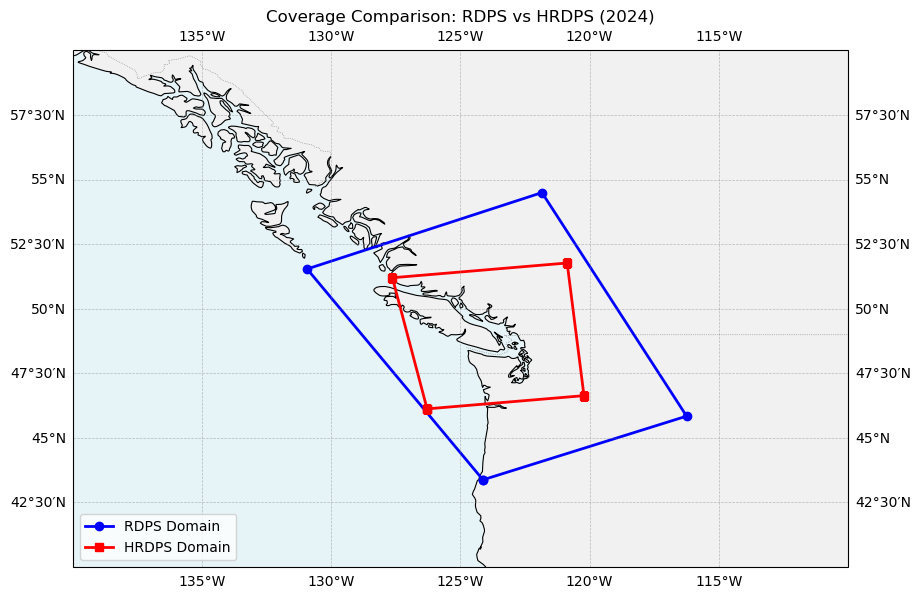

In [2]:
# Range Comparison
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

def get_valid_four_corners(file_path):
    """
    读取 nc 文件，过滤掉 (0,0) 的异常点，返回有效数据区域的四个顶点经纬度。
    """
    try:
        # 使用 xarray 读取数据
        ds = xr.open_dataset(file_path)
    except Exception as e:
        print(f"读取文件失败: {file_path}\n错误信息: {e}")
        return None, None

    # 尝试自动匹配经纬度变量名
    lat_vars = ['lat', 'latitude', 'nav_lat']
    lon_vars = ['lon', 'longitude', 'nav_lon']
    
    lat_name = next((var for var in lat_vars if var in ds.variables), None)
    lon_name = next((var for var in lon_vars if var in ds.variables), None)
    
    if not lat_name or not lon_name:
        print(f"在 {file_path} 中找不到常规的经纬度变量名。")
        return None, None

    lat = ds[lat_name].values
    lon = ds[lon_name].values

    # 如果经纬度是 1D 的，将其转换为 2D 网格
    if lat.ndim == 1 and lon.ndim == 1:
        lon, lat = np.meshgrid(lon, lat)

    # 统一将经度转换到 -180 到 180 的范围（以防有些数据是 0 到 360）
    lon = np.where(lon > 180, lon - 360, lon)

    # 核心步骤：过滤掉 lat=0 且 lon=0 的无效点，以及 NaN 值
    valid_mask = ~((np.isclose(lat, 0)) & (np.isclose(lon, 0))) & ~np.isnan(lat) & ~np.isnan(lon)
    
    # 找到有效数据在矩阵中的行列索引范围
    valid_y, valid_x = np.where(valid_mask)
    if len(valid_y) == 0:
        print(f"文件 {file_path} 中没有找到有效的经纬度数据。")
        return None, None

    y_min, y_max = valid_y.min(), valid_y.max()
    x_min, x_max = valid_x.min(), valid_x.max()

    # 提取四个顶点：左下、右下、右上、左上
    corners_lon = [
        lon[y_min, x_min], lon[y_min, x_max], 
        lon[y_max, x_max], lon[y_max, x_min]
    ]
    corners_lat = [
        lat[y_min, x_min], lat[y_min, x_max], 
        lat[y_max, x_max], lat[y_max, x_min]
    ]
    
    # 闭合多边形（将第一个点加到最后）
    corners_lon.append(corners_lon[0])
    corners_lat.append(corners_lat[0])

    ds.close()
    return corners_lon, corners_lat

def plot_domains():
    # 定义文件路径
    file_rdps = '/home/jqiu/Programing/Projects/analysis-junqi/Atmospheric_Forcing/Data_CaSR/Merged_Data_2024/Merged_CaSR_v3.2_P_FB_SFC_2024.nc'
    file_hrdps = '/results/forcing/atmospheric/continental2.5/nemo_forcing/hrdps_y2024m01d01.nc'

    # 获取边界坐标
    rdps_lon, rdps_lat = get_valid_four_corners(file_rdps)
    hrdps_lon, hrdps_lat = get_valid_four_corners(file_hrdps)

    # 初始化地图
    fig = plt.figure(figsize=(10, 8))
    # 中心经纬度大致设置在北美
    ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())
    
    # 添加地图特征（岸线、陆地、国界）
    ax.add_feature(cfeature.COASTLINE, linewidth=0.8, edgecolor='black')
    ax.add_feature(cfeature.BORDERS, linewidth=0.5, linestyle=':', edgecolor='gray')
    ax.add_feature(cfeature.LAND, facecolor='lightgray', alpha=0.3)
    ax.add_feature(cfeature.OCEAN, facecolor='lightblue', alpha=0.3)

    # 绘制 RDPS 范围（蓝色）
    if rdps_lon and rdps_lat:
        ax.plot(rdps_lon, rdps_lat, transform=ccrs.PlateCarree(), 
                color='blue', linewidth=2, label='RDPS Domain', marker='o')
        
    # 绘制 HRDPS 范围（红色）
    if hrdps_lon and hrdps_lat:
        ax.plot(hrdps_lon, hrdps_lat, transform=ccrs.PlateCarree(), 
                color='red', linewidth=2, label='HRDPS Domain', marker='s')

    # 设置地图显示范围（根据两个数据的最大最小经纬度自动缩放，或者手动写死）
    ax.set_global() 
    ax.set_extent([-140, -110, 40, 60], crs=ccrs.PlateCarree()) # 这里设定了大概的北美范围，可按需微调

    # 添加网格线和图例
    ax.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False, linewidth=0.5, color='gray', alpha=0.5, linestyle='--')
    plt.legend(loc='lower left')
    plt.title('Coverage Comparison: RDPS vs HRDPS (2024)')
    
    # 渲染显示，或者你也可以用 plt.savefig('domain_plot.png', dpi=300) 来保存图片
    plt.show()

if __name__ == '__main__':
    plot_domains()

## Variable Inspection

In [4]:
# NC Info
import xarray as xr

def print_nc_info(file_path):
    try:
        ds = xr.open_dataset(file_path)
    except Exception as e:
        print(f"读取文件失败: {e}")
        return

    print(f"=== {file_path.split('/')[-1]} 变量信息 ===\n")
    # 打印表头
    print(f"{'变量名 (Variable)':<15} | {'维度 (Dims)':<25} | {'类型 (dtype)':<10} | {'单位 (Units)':<15} | {'长名称 (Long Name)'}")
    print("-" * 90)

    # 遍历并打印每个变量的信息
    for var_name, var_data in ds.variables.items():
        dims = str(var_data.dims)
        dtype = str(var_data.dtype)
        attrs = var_data.attrs
        
        long_name = attrs.get('long_name', attrs.get('standard_name', ''))
        units = attrs.get('units', '')
        
        print(f"{var_name:<17} | {dims:<25} | {dtype:<12} | {units:<17} | {long_name}")

    ds.close()

if __name__ == '__main__':
    hrdps_file = '/results/forcing/atmospheric/continental2.5/nemo_forcing/hrdps_y2024m01d01.nc'
    print_nc_info(hrdps_file)

=== hrdps_y2024m01d01.nc 变量信息 ===

变量名 (Variable)  | 维度 (Dims)                 | 类型 (dtype) | 单位 (Units)      | 长名称 (Long Name)
------------------------------------------------------------------------------------------
LHTFL_surface     | ('time_counter', 'y', 'x') | float32      | W m-2             | Latent heat net flux
PRATE_surface     | ('time_counter', 'y', 'x') | float32      | kg m-2 s-1        | Precipitation rate
RH_2maboveground  | ('time_counter', 'y', 'x') | float32      | %                 | 2 metre relative humidity
atmpres           | ('time_counter', 'y', 'x') | float32      | Pa                | Air Pressure at MSL
precip            | ('time_counter', 'y', 'x') | float32      | kg m-2 s-1        | Precipitation Flux
qair              | ('time_counter', 'y', 'x') | float32      | kg kg-1           | Specific Humidity at 2m
solar             | ('time_counter', 'y', 'x') | float32      | W m-2             | Downward Short-Wave (Solar) Radiation Flux
tair              | (

| Physical Quantity    | HRDPS Variable         | HRDPS Unit | RDPS Variable       | RDPS Unit | Notes / Differences                                                 |
|----------------------|------------------------|------------|---------------------|-----------|---------------------------------------------------------------------|
| Air Temperature      | tair                   | K          | CaSR_v3.2_P_TT_1.5m | °C        | Different units; slight height difference (2m vs 1.5m).             |
| Specific Humidity    | qair                   | kg kg-1    | CaSR_v3.2_P_HU_1.5m | kg/kg     | Same units; slight height difference (2m vs 1.5m).                  |
| Precipitation        | precip / PRATE_surface | kg m-2 s-1 | CaSR_v3.2_P_PR0_SFC | m         | RDPS is accumulated (m), HRDPS is a rate/flux; requires conversion. |
| Short-Wave Radiation | solar                  | W m-2      | CaSR_v3.2_P_FB_SFC  | W/m²      | Downward solar flux; same units.                                    |
| Long-Wave Radiation  | therm_rad              | W m-2      | CaSR_v3.2_P_FI_SFC  | W/m²      | Surface incoming infrared flux; same units.                         |
| Sea Level Pressure   | atmpres                | Pa         | CaSR_v3.2_P_PN_SFC  | mb        | Different units (1 mb = 1 hPa = 100 Pa).                            |
| U-Wind (West-East)   | u_wind                 | m s-1      | CaSR_v3.2_P_UUC_10m | kts       | Different units (1 knot ≈ 0.5144 m/s).                              |
| V-Wind (South-North) | v_wind                 | m s-1      | CaSR_v3.2_P_VVC_10m | kts       | Different units (1 knot ≈ 0.5144 m/s).                              |

we need to think how to convert them into the data at the same height.

Variables Unique to **HRDPS**:

**LHTFL_surface**: Latent heat net flux (W m-2)

**RH_2maboveground**: 2-metre relative humidity (%) - Note: RDPS provides specific humidity but not direct relative humidity.

Not used in our SalishSeaCast.

## Error Comparison


In [2]:
# U-Wind Comparison
import xarray as xr
import numpy as np
import pandas as pd
from scipy.spatial import cKDTree
import random

def compare_u_wind_aligned():
    # 1. 固定随机种子，保证每次跑抽出来的点都一样
    random_seed = 42
    random.seed(random_seed)
    np.random.seed(random_seed)

    # 2. 定义文件路径
    rdps_file = '/home/jqiu/Programing/Projects/analysis-junqi/Atmospheric_Forcing/Data_CaSR/Data_2024/Merged_2024/CaSR_v3.2_P_UUC_10m_merged_2024.nc'
    hrdps_file = '/results/forcing/atmospheric/continental2.5/nemo_forcing/hrdps_y2024m01d01.nc'

    print("正在加载数据集...")
    try:
        ds_rdps = xr.open_dataset(rdps_file)
        ds_hrdps = xr.open_dataset(hrdps_file)
    except Exception as e:
        print(f"读取文件失败: {e}")
        return

    # 3. 时间对齐 (锁定 2024-01-01 12:00:00)
    target_time = '2024-01-01T12:00:00'
    print(f"正在对齐时间至: {target_time} ...")
    
    try:
        # RDPS 通常时间维度叫 time，HRDPS 叫 time_counter
        # 使用 method='nearest' 防止时间戳有几秒钟的微小误差导致报错
        rdps_step = ds_rdps.sel(time=target_time, method='nearest')
        hrdps_step = ds_hrdps.sel(time_counter=target_time, method='nearest')
    except Exception as e:
        print(f"时间对齐失败，请检查文件中的时间维度命名或时间范围: {e}")
        return

    # 4. 提取数据和经纬度
    # HRDPS 数据提取
    u_hrdps = hrdps_step['u_wind'].values
    lat_hrdps = ds_hrdps['nav_lat'].values
    lon_hrdps = ds_hrdps['nav_lon'].values
    # 确保 HRDPS 经度是 -180 到 180
    lon_hrdps = np.where(lon_hrdps > 180, lon_hrdps - 360, lon_hrdps)

    # RDPS 数据提取
    u_rdps_kts = rdps_step['CaSR_v3.2_P_UUC_10m'].values
    # 动态获取 RDPS 经纬度变量名
    lat_rdps_name = next((v for v in ['lat', 'latitude', 'nav_lat'] if v in ds_rdps.variables), None)
    lon_rdps_name = next((v for v in ['lon', 'longitude', 'nav_lon'] if v in ds_rdps.variables), None)
    lat_rdps = ds_rdps[lat_rdps_name].values
    lon_rdps = ds_rdps[lon_rdps_name].values
    # 确保 RDPS 经度也是 -180 到 180
    lon_rdps = np.where(lon_rdps > 180, lon_rdps - 360, lon_rdps)

    # 5. 构建 HRDPS 的 KDTree (因为我们这次要从 RDPS 找 HRDPS)
    print("正在构建 HRDPS 空间索引...")
    valid_hrdps_mask = ~np.isnan(lat_hrdps) & ~np.isnan(lon_hrdps) & ~np.isnan(u_hrdps) & ~((np.isclose(lat_hrdps, 0)) & (np.isclose(lon_hrdps, 0)))
    
    hrdps_coords = np.column_stack((lat_hrdps[valid_hrdps_mask], lon_hrdps[valid_hrdps_mask]))
    hrdps_u_values = u_hrdps[valid_hrdps_mask]
    
    tree = cKDTree(hrdps_coords)

    # 6. 在 RDPS 中随机抽样
    print("正在从 RDPS 抽样并寻找 HRDPS 对应点...")
    valid_rdps_mask = ~np.isnan(lat_rdps) & ~np.isnan(lon_rdps) & ~np.isnan(u_rdps_kts)
    valid_rdps_indices = np.where(valid_rdps_mask)
    
    num_samples = 15
    # 如果可用点少于要抽样的数量，就取全部可用点
    actual_samples = min(num_samples, len(valid_rdps_indices[0]))
    sample_idx = random.sample(range(len(valid_rdps_indices[0])), actual_samples)
    
    results = []
    
    for idx in sample_idx:
        # RDPS 如果是 1D 经纬度网格（很多时候低分辨率网格是 1D 的）
        if lat_rdps.ndim == 1:
            y_idx, x_idx = valid_rdps_indices[0][idx], valid_rdps_indices[1][idx]
            target_lat = lat_rdps[y_idx]
            target_lon = lon_rdps[x_idx]
        else: # 2D 网格
            y_idx, x_idx = valid_rdps_indices[0][idx], valid_rdps_indices[1][idx]
            target_lat = lat_rdps[y_idx, x_idx]
            target_lon = lon_rdps[y_idx, x_idx]
            
        rdps_u_val_kts = u_rdps_kts[y_idx, x_idx]
        
        # 核心：将 RDPS 转换为 m/s
        rdps_u_val_ms = rdps_u_val_kts * 0.514444
        
        # 在 HRDPS 中找最近点
        dist, hrdps_idx = tree.query([target_lat, target_lon], k=1)
        
        # 距离阈值：大概 0.2 度（视具体纬度而定，约 20km）。超出的说明 RDPS 点在 HRDPS 范围外
        if dist > 0.2:
            continue
            
        hrdps_u_val = hrdps_u_values[hrdps_idx]
        diff = hrdps_u_val - rdps_u_val_ms
        
        results.append({
            "Lat": f"{target_lat:.2f}",
            "Lon": f"{target_lon:.2f}",
            "RDPS (kts)": f"{rdps_u_val_kts:.3f}",
            "RDPS (m/s)": f"{rdps_u_val_ms:.3f}",
            "HRDPS (m/s)": f"{hrdps_u_val:.3f}",
            "Diff (H - R)": f"{diff:.3f}"
        })

    # 7. 输出结果
    if results:
        df = pd.DataFrame(results)
        print(f"\n=== U-Wind 随机抽样对比 (时间: {target_time}, 种子: {random_seed}) ===")
        print(df.to_markdown(index=False))
        
        mae = np.mean(np.abs(df['Diff (H - R)'].astype(float)))
        print(f"\n--> 这 {len(results)} 个有效点的平均绝对误差 (MAE) 约为: {mae:.3f} m/s")
    else:
        print("\n抽样的 RDPS 点均未在 HRDPS 覆盖范围内找到匹配点。这可能是由于两者空间交集较小，建议增加抽样数量 (num_samples)。")

    ds_rdps.close()
    ds_hrdps.close()

if __name__ == '__main__':
    compare_u_wind_aligned()

正在加载数据集...
正在对齐时间至: 2024-01-01T12:00:00 ...
正在构建 HRDPS 空间索引...
正在从 RDPS 抽样并寻找 HRDPS 对应点...

=== U-Wind 随机抽样对比 (时间: 2024-01-01T12:00:00, 种子: 42) ===
|   Lat |     Lon |   RDPS (kts) |   RDPS (m/s) |   HRDPS (m/s) |   Diff (H - R) |
|------:|--------:|-------------:|-------------:|--------------:|---------------:|
| 47.28 | -126.78 |       -5.21  |       -2.68  |        -0.969 |          1.711 |
| 49.25 | -126.71 |      -10.28  |       -5.288 |        -6.727 |         -1.438 |
| 50.28 | -122.37 |       -1.305 |       -0.672 |         0.206 |          0.878 |
| 48.56 | -126.92 |       -5.641 |       -2.902 |        -3.133 |         -0.231 |
| 48.4  | -124.49 |      -11.075 |       -5.697 |        -5.314 |          0.383 |
| 47.47 | -125.42 |       -9.799 |       -5.041 |        -4.153 |          0.888 |
| 51.16 | -126.25 |       -0.76  |       -0.391 |        -0.596 |         -0.205 |
| 48.38 | -120.44 |        1.302 |        0.67  |        -0.087 |         -0.757 |
| 47.78 | -122.39 |   

正在加载数据集...
正在处理经纬度并构建高分辨率 (HRDPS) 空间索引...
正在对比 4 个时刻的数据 (使用 IDW 插值)...
成功收集到 368 个对比对，正在生成图表...


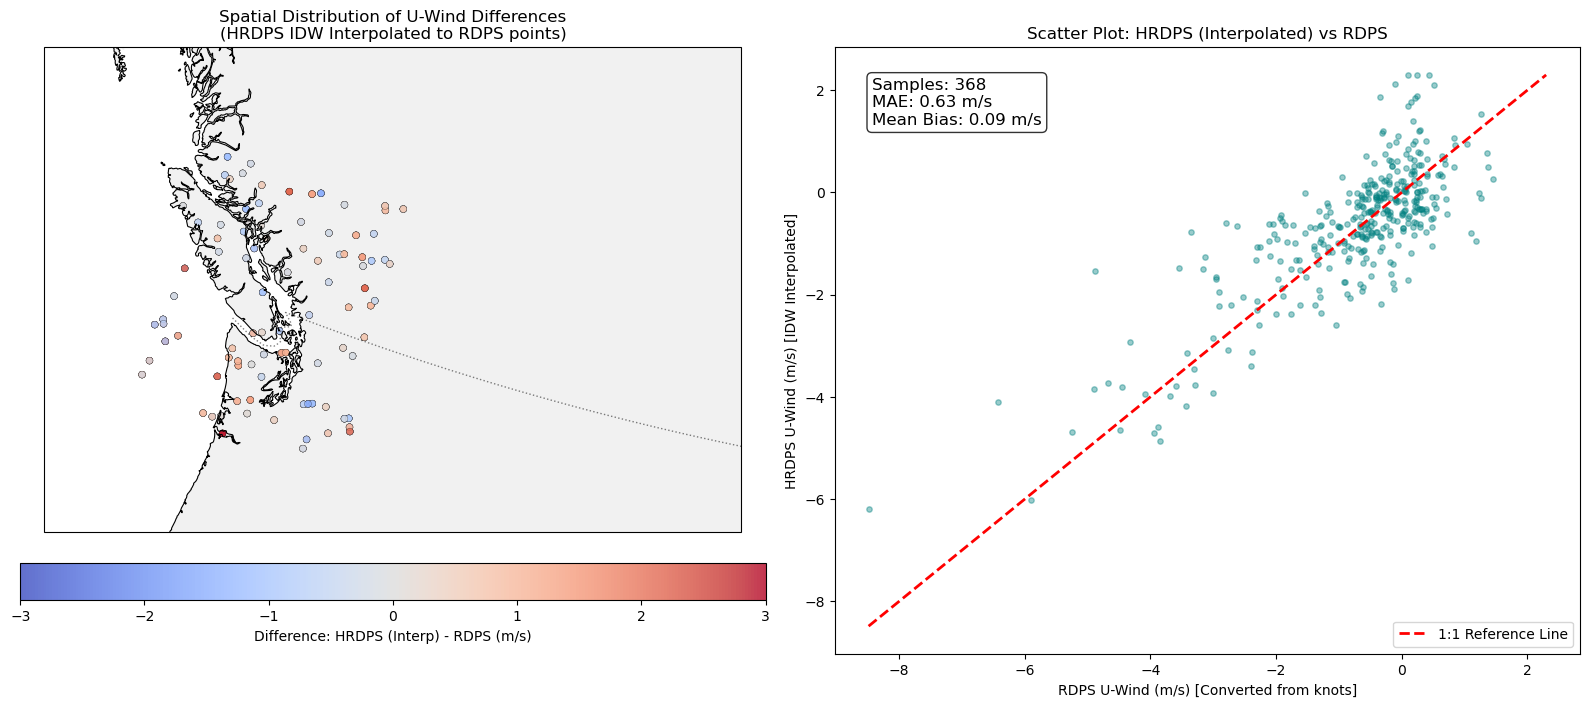

In [4]:
# Plot Comparison

import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from scipy.spatial import cKDTree
import random

def idw_interpolation(tree, target_lat, target_lon, hrdps_values_flat, k=4, power=2):
    """
    反距离加权插值 (Inverse Distance Weighting)
    """
    # 查找最近的 k 个点
    distances, indices = tree.query([target_lat, target_lon], k=k)
    
    # 如果其中有一个点的距离极其接近 0，直接返回该点的值（避免除以 0）
    if distances[0] < 1e-10:
        return hrdps_values_flat[indices[0]]
    
    # 计算权重（距离的倒数的 power 次方）
    weights = 1.0 / (distances ** power)
    
    # 计算加权平均值
    interpolated_value = np.sum(weights * hrdps_values_flat[indices]) / np.sum(weights)
    return interpolated_value


def plot_wind_difference():
    # 1. 设置随机种子，保证可重复性
    random.seed(42)
    np.random.seed(42)

    # 2. 文件路径
    rdps_file = '/home/jqiu/Programing/Projects/analysis-junqi/Atmospheric_Forcing/Data_CaSR/Merged_Data_2024/Merged_CaSR_v3.2_P_UUC_10m_2024.nc'
    hrdps_file = '/results/forcing/atmospheric/continental2.5/nemo_forcing/hrdps_y2024m01d01.nc'

    print("正在加载数据集...")
    ds_rdps = xr.open_dataset(rdps_file)
    ds_hrdps = xr.open_dataset(hrdps_file)

    # 3. 提取经纬度并构建 HRDPS 的 KDTree (反转：建在高清数据上)
    print("正在处理经纬度并构建高分辨率 (HRDPS) 空间索引...")
    lat_hrdps = ds_hrdps['nav_lat'].values
    lon_hrdps = ds_hrdps['nav_lon'].values
    lon_hrdps = np.where(lon_hrdps > 180, lon_hrdps - 360, lon_hrdps)
    
    # 过滤 HRDPS 无效坐标点
    valid_hrdps_mask = ~np.isnan(lat_hrdps) & ~((np.isclose(lat_hrdps, 0)) & (np.isclose(lon_hrdps, 0)))
    hrdps_coords = np.column_stack((lat_hrdps[valid_hrdps_mask], lon_hrdps[valid_hrdps_mask]))
    
    # 构建 HRDPS 的树
    tree_hrdps = cKDTree(hrdps_coords)

    # 处理 RDPS 经纬度
    lat_rdps_name = next((v for v in ['lat', 'latitude', 'nav_lat'] if v in ds_rdps.variables), None)
    lon_rdps_name = next((v for v in ['lon', 'longitude', 'nav_lon'] if v in ds_rdps.variables), None)
    lat_rdps = ds_rdps[lat_rdps_name].values
    lon_rdps = ds_rdps[lon_rdps_name].values
    lon_rdps = np.where(lon_rdps > 180, lon_rdps - 360, lon_rdps)

    if lat_rdps.ndim == 1:
        lon_rdps_2d, lat_rdps_2d = np.meshgrid(lon_rdps, lat_rdps)
    else:
        lon_rdps_2d, lat_rdps_2d = lon_rdps, lat_rdps

    # 4. 在 RDPS 中随机抽取有效点作为采样基准
    valid_rdps_mask = ~np.isnan(lat_rdps_2d) & ~np.isnan(lon_rdps_2d)
    valid_rdps_indices = np.where(valid_rdps_mask)
    num_samples = 200
    sample_idx = random.sample(range(len(valid_rdps_indices[0])), num_samples)

    # 选取 2024年1月1日的 4 个时刻
    target_times = ['2024-01-01T00:00:00', '2024-01-01T06:00:00', 
                    '2024-01-01T12:00:00', '2024-01-01T18:00:00']

    all_rdps_u_ms = []
    all_hrdps_u_interp = []
    all_lats = []
    all_lons = []
    all_diffs = []

    print(f"正在对比 {len(target_times)} 个时刻的数据 (使用 IDW 插值)...")

    for t_str in target_times:
        try:
            # 提取数据
            h_step = ds_hrdps.sel(time_counter=t_str, method='nearest')['u_wind'].values
            r_step = ds_rdps.sel(time=t_str, method='nearest')['CaSR_v3.2_P_UUC_10m'].values
            
            # 拉平 HRDPS 数据以对应 KDTree 的索引
            h_step_flat = h_step[valid_hrdps_mask]

            for idx in sample_idx:
                y_idx, x_idx = valid_rdps_indices[0][idx], valid_rdps_indices[1][idx]
                t_lat, t_lon = lat_rdps_2d[y_idx, x_idx], lon_rdps_2d[y_idx, x_idx]
                
                # 获取 RDPS 基准风速 (转换为 m/s)
                r_u_kts = r_step[y_idx, x_idx]
                if np.isnan(r_u_kts): continue
                r_u_ms = r_u_kts * 0.514444

                # 检查距离 (确保 RDPS 点在 HRDPS 覆盖范围内)
                dist_nearest, _ = tree_hrdps.query([t_lat, t_lon], k=1)
                if dist_nearest > 0.2: 
                    continue # 如果最近的点都很远，说明越界了

                # 在 HRDPS 场中执行 IDW 插值
                h_u_interp = idw_interpolation(tree_hrdps, t_lat, t_lon, h_step_flat, k=4)
                
                if np.isnan(h_u_interp): continue

                all_rdps_u_ms.append(r_u_ms)
                all_hrdps_u_interp.append(h_u_interp)
                all_lats.append(t_lat)
                all_lons.append(t_lon)
                # 计算差异 (高分辨率 - 低分辨率基准)
                all_diffs.append(h_u_interp - r_u_ms)
                
        except Exception as e:
            print(f"处理时刻 {t_str} 时出错: {e}")
            continue

    ds_rdps.close()
    ds_hrdps.close()

    if not all_rdps_u_ms:
        print("没有收集到有效数据点，请检查时间或坐标匹配。")
        return

    # 5. 开始画图
    print(f"成功收集到 {len(all_rdps_u_ms)} 个对比对，正在生成图表...")
    fig = plt.figure(figsize=(16, 7))

    # --- 子图 1: 空间误差分布地图 ---
    ax1 = fig.add_subplot(1, 2, 1, projection=ccrs.LambertConformal(central_longitude=-90, central_latitude=50))
    ax1.set_extent([-130, -110, 47, 53], crs=ccrs.PlateCarree()) # 温哥华周边
    
    ax1.add_feature(cfeature.COASTLINE, linewidth=0.8)
    ax1.add_feature(cfeature.BORDERS, linestyle=':', alpha=0.5)
    ax1.add_feature(cfeature.LAND, facecolor='lightgray', alpha=0.3)

    # 散点图
    sc = ax1.scatter(all_lons, all_lats, c=all_diffs, cmap='coolwarm', 
                     vmin=-3, vmax=3, s=25, alpha=0.8, edgecolors='k', linewidth=0.2, transform=ccrs.PlateCarree())
    plt.colorbar(sc, ax=ax1, orientation='horizontal', pad=0.05, label='Difference: HRDPS (Interp) - RDPS (m/s)')
    ax1.set_title('Spatial Distribution of U-Wind Differences\n(HRDPS IDW Interpolated to RDPS points)')

    # --- 子图 2: 散点相关性图 ---
    ax2 = fig.add_subplot(1, 2, 2)
    ax2.scatter(all_rdps_u_ms, all_hrdps_u_interp, alpha=0.4, s=15, color='teal')
    
    # 画 1:1 对角线
    min_val = min(min(all_rdps_u_ms), min(all_hrdps_u_interp))
    max_val = max(max(all_rdps_u_ms), max(all_hrdps_u_interp))
    ax2.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='1:1 Reference Line')
    
    # 统计信息
    mae = np.mean(np.abs(np.array(all_diffs)))
    bias = np.mean(np.array(all_diffs))
    
    ax2.set_xlabel('RDPS U-Wind (m/s) [Converted from knots]')
    ax2.set_ylabel('HRDPS U-Wind (m/s) [IDW Interpolated]')
    ax2.set_title('Scatter Plot: HRDPS (Interpolated) vs RDPS')
    ax2.legend()
    
    stats_text = f"Samples: {len(all_rdps_u_ms)}\nMAE: {mae:.2f} m/s\nMean Bias: {bias:.2f} m/s"
    ax2.text(0.05, 0.95, stats_text, transform=ax2.transAxes, fontsize=12,
             verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

    plt.tight_layout()
    plt.show()

if __name__ == '__main__':
    plot_wind_difference()

## Height Difference

There are slight height differences (2m vs 1.5m) for Air Temperature Specific Humidity in HRDPS and RDPS.

### Option 1: Monin-Obukhov Similarity Theory (MOST): Forget about it.

Maybe we can use MOST to convert height. I believe we need T* and q* (simular to u*)? 

### Option 2: Just ignore it

In so far, the most practical solution is to ignore the height difference.




# Full Download

In the following section, I will down load full data from 2008 to 2024 (including 2011 to 2018) to ocean/jqiu.

Download years that include 2011 and 2018 to ocean/jqiu. Note that we might need to cd to it through terminal before we are able to access it via VS Code.

In [1]:
# Full Download

import os
import subprocess

import os
import requests
from concurrent.futures import ThreadPoolExecutor, as_completed
from tqdm import tqdm

# ================= 配置区域 =================
file_list = "/home/jqiu/Programing/Projects/analysis-junqi/Atmospheric_Forcing/Data_CaSR/CaSRv3p2_file-list_full.txt"
target_dir = "/ocean/jqiu/Atmospheric_RDPS/2008_2024_Raw/"
base_url = "https://hpfx.collab.science.gc.ca/~scar700/rcas-casr/data/CaSRv3.2/netcdf_tile/"

# 最大并发线程数（建议 4-8，太高可能会被服务器封 IP）
MAX_WORKERS = 5 
# ============================================

os.makedirs(target_dir, exist_ok=True)

def download_file(filename):
    """负责处理单个文件下载的核心函数，支持断点续传"""
    full_url = base_url + filename if not filename.startswith("http") else filename
    # 提取纯文件名，防止带路径导致报错
    safe_filename = filename.split('/')[-1] 
    target_path = os.path.join(target_dir, safe_filename)
    
    try:
        # 1. 先发送 HEAD 请求，只获取文件的基本信息（不下载内容），目的是拿到服务器上的文件总大小
        head_response = requests.head(full_url, timeout=10)
        head_response.raise_for_status()
        remote_size = int(head_response.headers.get('content-length', 0))
        
        # 2. 检查本地是否已经有这个文件，以及它的大小
        local_size = 0
        if os.path.exists(target_path):
            local_size = os.path.getsize(target_path)
            
        # 3. 核心逻辑：比对大小
        if remote_size > 0 and local_size == remote_size:
            return True, f"Skipped (Already fully downloaded)" # 本地与云端一样大，直接跳过
            
        headers = {}
        mode = 'wb' # 默认覆盖写入
        
        if 0 < local_size < remote_size:
            # 本地有文件但没下完，构造 Range 请求头告诉服务器“从这里接着传”
            headers['Range'] = f"bytes={local_size}-"
            mode = 'ab' # 调整为追加写入模式 (append binary)
            
        elif local_size > remote_size:
            # 异常情况：本地文件比服务器还大（可能文件损坏），从头开始下
            local_size = 0 
            
        # 4. 开始实际下载 (stream=True 保证内存不会爆掉)
        with requests.get(full_url, headers=headers, stream=True, timeout=15) as r:
            r.raise_for_status()
            with open(target_path, mode) as f:
                for chunk in r.iter_content(chunk_size=8192): # 每次写入 8KB
                    if chunk:
                        f.write(chunk)
                        
        return True, "Success"
        
    except Exception as e:
        return False, f"Failed: {str(e)}"

# ================= 主程序 =================
if __name__ == "__main__":
    if not os.path.exists(file_list):
        print(f"No path found: {file_list}")
    else:
        # 读取并过滤空行
        with open(file_list, 'r') as f:
            files_to_download = [line.strip() for line in f if line.strip()]
            
        total_files = len(files_to_download)
        print(f"Target Path: {target_dir}")
        print(f" Max Workers: {MAX_WORKERS}  Total Files: {total_files}\n")
        
        success_count = 0
        failed_files = []
        
        # 使用线程池并发执行下载
        with ThreadPoolExecutor(max_workers=MAX_WORKERS) as executor:
            # 提交所有任务到线程池，并将任务与文件名绑定
            future_to_file = {executor.submit(download_file, fname): fname for fname in files_to_download}
            
            # 使用 tqdm 包装 as_completed，哪个文件先下完，进度条就涨一下
            for future in tqdm(as_completed(future_to_file), total=total_files, desc="总进度", unit="file"):
                fname = future_to_file[future]
                try:
                    is_success, msg = future.result()
                    if is_success:
                        success_count += 1
                    else:
                        failed_files.append((fname, msg))
                        # 只有在发生错误时才在终端打印，不干扰进度条
                        tqdm.write(f" {fname} -> {msg}")
                except Exception as exc:
                    failed_files.append((fname, str(exc)))
                    tqdm.write(f" {fname} Fatal Error: {exc}")
                    
        # 最终统计报告
        print("\n" + "="*40)
        print(f"Success: {success_count}/{total_files}")
        if failed_files:
            print(f"Failed: {len(failed_files)}")
            print("Error Details:")
            for name, error in failed_files:
                print(f" - {name}: {error}")
        print("="*40)

Target Path: /ocean/jqiu/Atmospheric_RDPS/2008_2024_Raw/
 Max Workers: 5  Total Files: 240



总进度: 100%|██████████| 240/240 [05:51<00:00,  1.47s/file]


Success: 240/240


In [3]:
# Data Merger

import xarray as xr
import glob
import os
import warnings
from tqdm import tqdm

# 禁用 HDF5 文件锁，屏蔽部分底层报错
os.environ['HDF5_USE_FILE_LOCKING'] = 'FALSE'
os.environ['HDF5_DISABLE_VERSION_CHECK'] = '1'

# 路径
base_dir = '/ocean/jqiu/Atmospheric_RDPS/2008_2024_Raw/'
output_dir = '/ocean/jqiu/Atmospheric_RDPS/2008_2024_Integrated/'
os.makedirs(output_dir, exist_ok=True)

# 变量
variables = [
    'P_FB_SFC', 'P_FI_SFC', 'P_HU_1.5m', 'P_PN_SFC', 
    'P_PR0_SFC', 'P_TT_1.5m', 'P_UUC_10m', 'P_VVC_10m'
]

for var in tqdm(variables, desc="Merging Variables", unit="var"):
    
    # 匹配对应变量的所有文件，使用更通用的匹配模式适应 RDPS
    # 如果你的文件名有固定的前缀，比如 'RDPS_v1.0_...'，可以改成 f'RDPS_v1.0_{var}_*.nc'
    search_pattern = os.path.join(base_dir, f'*{var}*.nc')
    all_files = sorted(glob.glob(search_pattern))
    
    # 文件体检（过滤掉太小的损坏文件，阈值 10KB）
    valid_files = [f for f in all_files if os.path.getsize(f) > 10240]
    invalid_count = len(all_files) - len(valid_files)
    
    if invalid_count > 0:
        tqdm.write(f"Attention: {var} Found {invalid_count} corrupted files, automatically skipped!")
        
    if not valid_files:
        tqdm.write(f"Error: {var} No valid files found in {base_dir}, skipping variable.")
        continue

    try:
        with warnings.catch_warnings():
            warnings.simplefilter("ignore", FutureWarning)
            
            # 读取并合并所有文件
            combined = xr.open_mfdataset(
                valid_files, 
                combine='by_coords', 
                parallel=True,
                data_vars='minimal', 
                engine='netcdf4',
                chunks='auto' 
            )
        
        # 尝试继承第一个文件中的地图投影坐标属性（兼容判断，防止 RDPS 没有该变量而报错）
        with xr.open_dataset(valid_files[0], engine='netcdf4') as ds:
            if 'rotated_pole' in ds:
                combined['rotated_pole'] = ds['rotated_pole']
        
        # 保存
        output_file = os.path.join(output_dir, f"Integrated_RDPS_{var}_2008_2024.nc")
        
        # 【使用 h5netcdf 引擎和 mode='w' 覆盖模式，彻底消灭 HDF5 底层红字报错！
        combined.to_netcdf(
            output_file, 
            mode='w',
            unlimited_dims='time', 
            engine='h5netcdf'
        )
        tqdm.write(f"Successfully merged {var} into {output_file}")
        
        # 释放内存
        combined.close()
        
    except Exception as e:
        tqdm.write(f"Error processing {var}: {e}")

print(f"\n All variables processed! Integrated files are saved in: {output_dir}")

Merging Variables:  12%|█▎        | 1/8 [01:30<10:35, 90.78s/var]

Successfully merged P_FB_SFC into /ocean/jqiu/Atmospheric_RDPS/2008_2024_Integrated/Integrated_RDPS_P_FB_SFC_2008_2024.nc


Merging Variables:  25%|██▌       | 2/8 [03:40<11:21, 113.61s/var]

Successfully merged P_FI_SFC into /ocean/jqiu/Atmospheric_RDPS/2008_2024_Integrated/Integrated_RDPS_P_FI_SFC_2008_2024.nc


Merging Variables:  38%|███▊      | 3/8 [06:01<10:31, 126.27s/var]

...

Successfully merged P_TT_1.5m into /ocean/jqiu/Atmospheric_RDPS/2008_2024_Integrated/Integrated_RDPS_P_TT_1.5m_2008_2024.nc


Merging Variables:  88%|████████▊ | 7/8 [16:14<02:36, 156.99s/var]

Successfully merged P_UUC_10m into /ocean/jqiu/Atmospheric_RDPS/2008_2024_Integrated/Integrated_RDPS_P_UUC_10m_2008_2024.nc


Merging Variables: 100%|██████████| 8/8 [19:26<00:00, 145.79s/var]

Successfully merged P_VVC_10m into /ocean/jqiu/Atmospheric_RDPS/2008_2024_Integrated/Integrated_RDPS_P_VVC_10m_2008_2024.nc

 All variables processed! Integrated files are saved in: /ocean/jqiu/Atmospheric_RDPS/2008_2024_Integrated/
